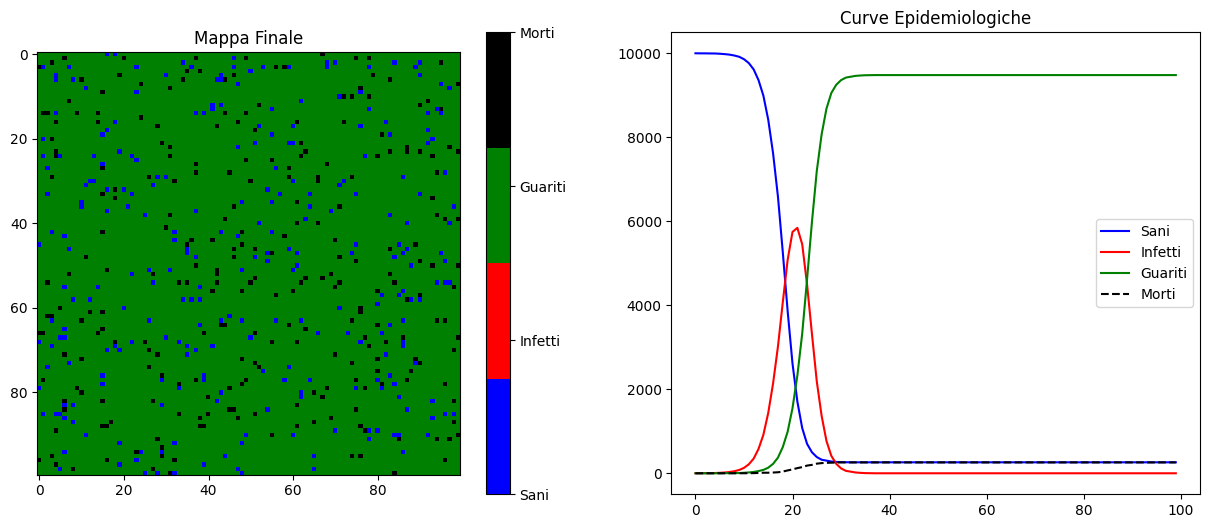

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib.colors import ListedColormap

# 1. PARAMETRI
DIM = 100
PROB_CONTAGIO = 0.20
PROB_MORTE = 0.005    # probabilità di morire ogni giorno che si è malati
GIORNI_MALATTIA = 5
PASSI_TEMPO = 100   #giorni passati
MOVIMENTO = True  # se True le persone si spostano

# Stati: 0=Sano, 1=Infetto, 2=Guarito, 3=Deceduto
griglia = np.zeros((DIM, DIM))
tempo_infezione = np.zeros((DIM, DIM))
griglia[DIM//2, DIM//2] = 1 # Paziente zero al centro
#griglia[0, 0] = 1 # Parte dall'angolo in alto a sinistra (togliendo commento)
#griglia[10, 10] = 1 # Focolaio A (aggiunge focolai togliendo commento)
#griglia[80, 80] = 1 # Focolaio B

storico_sani, storico_infetti, storico_guariti, storico_morti = [], [], [], []

# 2. SIMULAZIONE
for t in range(PASSI_TEMPO):
    storico_sani.append(np.sum(griglia == 0))
    storico_infetti.append(np.sum(griglia == 1))
    storico_guariti.append(np.sum(griglia == 2))
    storico_morti.append(np.sum(griglia == 3))

    if MOVIMENTO:
        for _ in range(DIM * DIM // 4):
            x1, y1 = random.randint(0, DIM-1), random.randint(0, DIM-1)
            x2, y2 = random.randint(0, DIM-1), random.randint(0, DIM-1)
            # Solo chi è vivo può muoversi (Stato < 3)
            if griglia[x1, y1] < 3 and griglia[x2, y2] < 3:
                griglia[x1, y1], griglia[x2, y2] = griglia[x2, y2], griglia[x1, y1]
                tempo_infezione[x1, y1], tempo_infezione[x2, y2] = tempo_infezione[x2, y2], tempo_infezione[x1, y1]

    nuova_griglia = griglia.copy()
    for x in range(DIM):
        for y in range(DIM):
            if griglia[x, y] == 1: # Se infetto
                # Test morte
                if random.random() < PROB_MORTE:
                    nuova_griglia[x, y] = 3
                else:
                    # Se non muore, Test contagio
                    for dx, dy in [(0,1), (0,-1), (1,0), (-1,0)]:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < DIM and 0 <= ny < DIM:
                            if griglia[nx, ny] == 0 and random.random() < PROB_CONTAGIO:
                                nuova_griglia[nx, ny] = 1

                    # Timer guarigione
                    tempo_infezione[x, y] += 1
                    if tempo_infezione[x, y] >= GIORNI_MALATTIA:
                        nuova_griglia[x, y] = 2

    griglia = nuova_griglia

# 3. VISUALIZZAZIONE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Mappa colori: Blu (Sano), Rosso (Infetto), Verde (Guarito), Nero (Morto)
colori = ListedColormap(['blue', 'red', 'green', 'black'])

ax1.set_title("Mappa Finale")
mappa = ax1.imshow(griglia, cmap=colori, vmin=0, vmax=3)
plt.colorbar(mappa, ax=ax1, ticks=[0, 1, 2, 3]).ax.set_yticklabels(['Sani', 'Infetti', 'Guariti', 'Morti'])

ax2.set_title("Curve Epidemiologiche")
ax2.plot(storico_sani, color='blue', label='Sani')
ax2.plot(storico_infetti, color='red', label='Infetti')
ax2.plot(storico_guariti, color='green', label='Guariti')
ax2.plot(storico_morti, color='black', label='Morti', linestyle='--')
ax2.legend()

plt.show()